# Titanic Dataset - Complete ML Pipeline
## From Data Exploration to Model Evaluation

This notebook demonstrates a complete machine learning workflow for predicting Titanic survival.

## Step 1: Import Libraries & Load Data
We start by importing necessary libraries for data manipulation, exploration, visualization, and machine learning.

In [23]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [24]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [25]:
print('Dimensions of the datasets:')
print('Training Dataset:', df_train.shape[0], 'rows ×', df_train.shape[1], 'columns')
print('Test Dataset:', df_test.shape[0], 'rows ×', df_test.shape[1], 'columns')

Dimensions of the datasets:
Training Dataset: 891 rows × 12 columns
Test Dataset: 418 rows × 11 columns


In [26]:
print("First 5 rows of the training dataset:")
df_train.head(5)

First 5 rows of the training dataset:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 2: Exploratory Data Analysis (EDA)
Understanding your data is crucial. We examine structure, missing values, distributions, and relationships.

In [27]:
# Check dataset info and missing values
print("Dataset Info:")
print(df_train.info())
print("\n" + "="*50)
print("\nMissing Values:")
missing = pd.DataFrame({
    'Column': df_train.columns,
    'Missing_Count': df_train.isnull().sum(),
    'Missing_Percentage': (df_train.isnull().sum() / len(df_train)) * 100
})
print(missing[missing['Missing_Count'] > 0])

print("\n" + "="*50)
print("\nBasic Statistics:")
print(df_train.describe())

print("\n" + "="*50)
print("\nTarget Variable Distribution (Survived):")
print(df_train['Survived'].value_counts())
print("\nSurvival Rate: {:.2f}%".format(df_train['Survived'].mean() * 100))

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


Missing Values:
            Column  Missing_Count  Missing_Percentage
Age            Age            177           19.865320
Cabin        Cabin            687           77.104377
Embarked  Embarked              2            

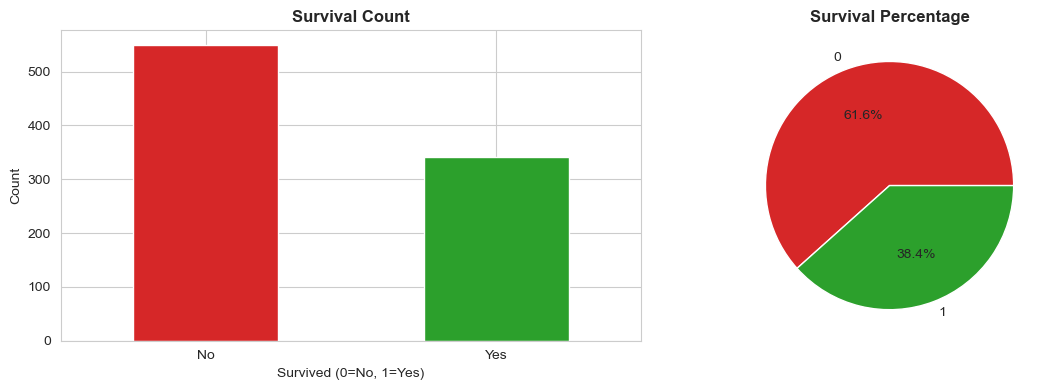

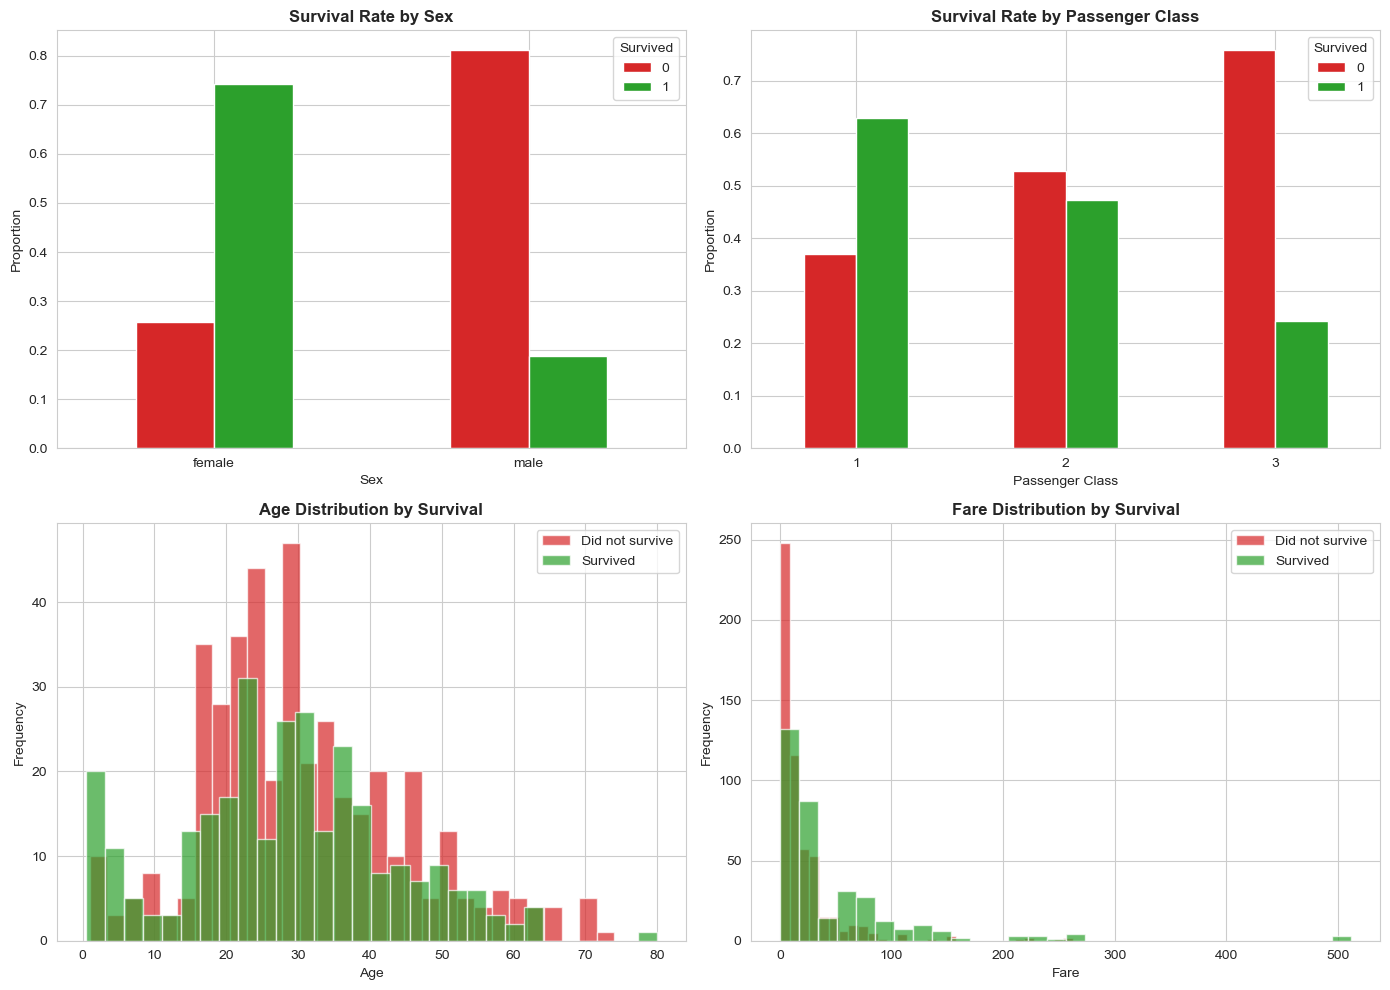

In [28]:
# Visualization: Survival Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Survival count plot
df_train['Survived'].value_counts().plot(kind='bar', ax=axes[0], color=['#d62728', '#2ca02c'])
axes[0].set_title('Survival Count', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Survived (0=No, 1=Yes)')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No', 'Yes'], rotation=0)

# Survival percentage
survival_pct = df_train['Survived'].value_counts(normalize=True) * 100
survival_pct.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', colors=['#d62728', '#2ca02c'])
axes[1].set_title('Survival Percentage', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# Feature Analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Survival by Sex
pd.crosstab(df_train['Sex'], df_train['Survived'], normalize='index').plot(kind='bar', ax=axes[0, 0], color=['#d62728', '#2ca02c'])
axes[0, 0].set_title('Survival Rate by Sex', fontweight='bold')
axes[0, 0].set_xlabel('Sex')
axes[0, 0].set_ylabel('Proportion')
axes[0, 0].set_xticklabels(axes[0, 0].get_xticklabels(), rotation=0)

# Survival by Pclass
pd.crosstab(df_train['Pclass'], df_train['Survived'], normalize='index').plot(kind='bar', ax=axes[0, 1], color=['#d62728', '#2ca02c'])
axes[0, 1].set_title('Survival Rate by Passenger Class', fontweight='bold')
axes[0, 1].set_xlabel('Passenger Class')
axes[0, 1].set_ylabel('Proportion')
axes[0, 1].set_xticklabels(axes[0, 1].get_xticklabels(), rotation=0)

# Age distribution by Survival
df_train[df_train['Survived']==0]['Age'].plot(kind='hist', ax=axes[1, 0], bins=30, alpha=0.7, label='Did not survive', color='#d62728')
df_train[df_train['Survived']==1]['Age'].plot(kind='hist', ax=axes[1, 0], bins=30, alpha=0.7, label='Survived', color='#2ca02c')
axes[1, 0].set_title('Age Distribution by Survival', fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Fare distribution by Survival
df_train[df_train['Survived']==0]['Fare'].plot(kind='hist', ax=axes[1, 1], bins=30, alpha=0.7, label='Did not survive', color='#d62728')
df_train[df_train['Survived']==1]['Fare'].plot(kind='hist', ax=axes[1, 1], bins=30, alpha=0.7, label='Survived', color='#2ca02c')
axes[1, 1].set_title('Fare Distribution by Survival', fontweight='bold')
axes[1, 1].set_xlabel('Fare')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

## Step 3: Data Preprocessing & Feature Engineering
This step prepares data for modeling by handling missing values, encoding categorical variables, and creating new features.

In [29]:
# Create a copy for preprocessing
df = df_train.copy()

# 1. Handle Missing Values
print("Handling Missing Values...")

# Fill Age with median (stratified by Pclass for better imputation)
df['Age'].fillna(df.groupby('Pclass')['Age'].transform('median'), inplace=True)

# Fill Embarked with mode (most frequent value)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Check if any missing values remain
print("Missing values after imputation:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# 2. Feature Engineering
print("\nCreating New Features...")

# Create family size feature
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# Create is_alone feature
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

# Create title extraction from Name
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)

# Simplify titles
df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')

# Age bins (categorical)
df['AgeBin'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])

# Fare bins (categorical)
df['FareBin'] = pd.qcut(df['Fare'], q=4, duplicates='drop', labels=['Low', 'Medium', 'High', 'Very High'])

print("New features created:", df.columns.difference(df_train.columns).tolist())

# 3. Encode Categorical Variables
print("\nEncoding Categorical Variables...")

# Sex encoding
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})

# Embarked encoding
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# Title encoding
title_mapping = {title: idx for idx, title in enumerate(df['Title'].unique())}
df['Title'] = df['Title'].map(title_mapping)

# AgeBin encoding
age_bin_mapping = {'Child': 0, 'Teen': 1, 'Adult': 2, 'Middle-aged': 3, 'Senior': 4}
df['AgeBin'] = df['AgeBin'].map(age_bin_mapping)

# FareBin encoding
fare_bin_mapping = {cat: idx for idx, cat in enumerate(['Low', 'Medium', 'High', 'Very High'])}
df['FareBin'] = df['FareBin'].map(fare_bin_mapping)

# Drop unnecessary columns
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

print("\nProcessed Dataset:")
print(df.head())
print("\nFinal Dataset Shape:", df.shape)

Handling Missing Values...
Missing values after imputation:
Cabin    687
dtype: int64

Creating New Features...
New features created: ['AgeBin', 'FamilySize', 'FareBin', 'IsAlone', 'Title']

Encoding Categorical Variables...

Processed Dataset:
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  Embarked  FamilySize  \
0         0       3    1  22.0      1      0   7.2500         0           2   
1         1       1    0  38.0      1      0  71.2833         1           2   
2         1       3    0  26.0      0      0   7.9250         0           1   
3         1       1    0  35.0      1      0  53.1000         0           2   
4         0       3    1  35.0      0      0   8.0500         0           1   

   IsAlone  Title AgeBin FareBin  
0        0      0      2       0  
1        0      1      3       3  
2        1      2      2       1  
3        0      1      2       3  
4        1      0      2       1  

Final Dataset Shape: (891, 13)


## Step 3.5: Feature Selection - Decision Making Guide

Feature selection is the process of identifying and selecting the most relevant features for your model. This reduces noise, improves performance, decreases training time, and enhances interpretability.

### When to Use Feature Selection:
- **High dimensionality**: Too many features relative to samples
- **Multicollinearity**: Features are highly correlated with each other
- **Noise**: Irrelevant features reduce model performance
- **Computational constraints**: Need faster training/prediction
- **Interpretability**: Want to understand which features matter

### Methods to Choose From:

**1. Correlation Analysis** ✓ Best for: Understanding linear relationships, reducing redundancy
   - Identifies highly correlated features
   - Remove one feature if correlation > 0.9
   
**2. Statistical Tests** ✓ Best for: Feature-target relationships
   - Chi-square: Categorical → Categorical target
   - Mutual Information: Any feature type
   - Correlation coefficient: Numerical → Numerical target
   
**3. Model-Based Selection** ✓ Best for: Feature importance from tree models
   - Tree models provide feature importance scores
   - Quick and computationally efficient
   
**4. Recursive Feature Elimination (RFE)** ✓ Best for: Eliminating less important features iteratively
   - Trains model, removes worst features, repeats
   - Most comprehensive but slower
   
**5. L1 Regularization (Lasso)** ✓ Best for: Linear models, automatic feature selection
   - Shrinks coefficients to zero for unimportant features

### Decision Framework:
1. Start with correlation analysis (quick, identify redundancy)
2. Use statistical tests for feature-target relationships
3. Apply model-based selection for importance
4. Validate with RFE if needed
5. Compare model performance with/without selected features

FEATURE SELECTION METHOD 1: CORRELATION ANALYSIS

Goal: Identify and remove highly correlated features (multicollinearity)
Rule: If correlation > 0.9 between two features, consider removing one

Features with high correlation (> 0.9): ['AgeBin']


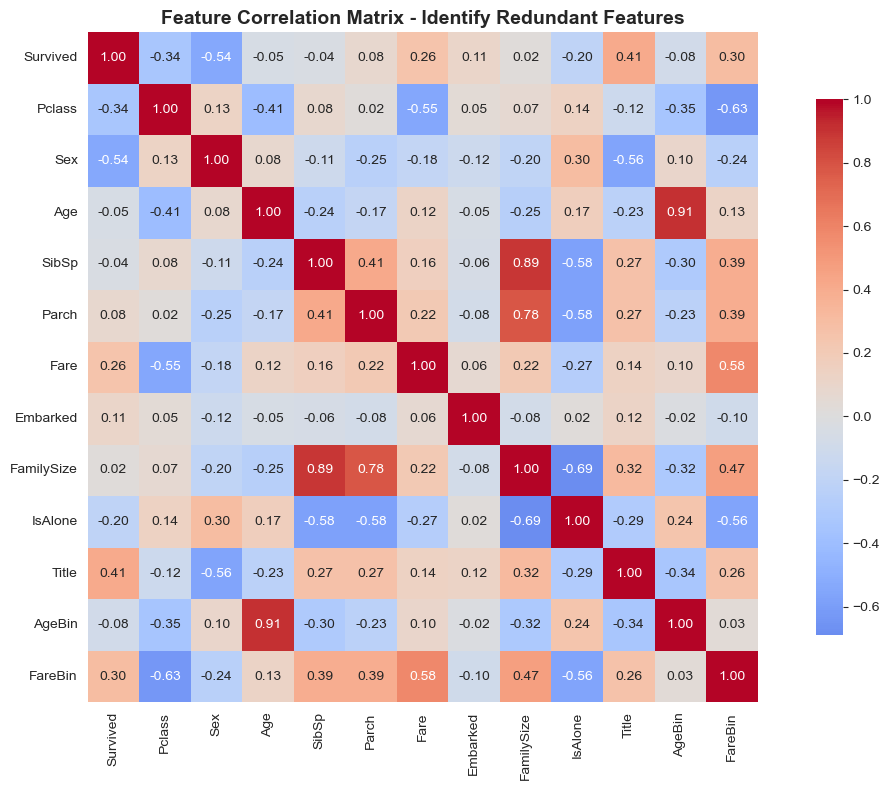


⚠ Action: Consider removing these features to reduce redundancy

Features to keep after correlation analysis: ['Age', 'Embarked', 'FamilySize', 'Fare', 'FareBin', 'IsAlone', 'Parch', 'Pclass', 'Sex', 'SibSp', 'Survived', 'Title']



In [38]:
# METHOD 1: CORRELATION ANALYSIS - Remove Multicollinearity
print("="*70)
print("FEATURE SELECTION METHOD 1: CORRELATION ANALYSIS")
print("="*70)
print("\nGoal: Identify and remove highly correlated features (multicollinearity)")
print("Rule: If correlation > 0.9 between two features, consider removing one\n")

# Calculate correlation matrix
correlation_matrix = df.corr()

# Get upper triangle of correlation matrix
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Find features with correlation > 0.9
high_corr_features = [column for column in upper_triangle.columns 
                       if any(upper_triangle[column].abs() > 0.9)]

print(f"Features with high correlation (> 0.9): {high_corr_features}")

# Visualize correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix - Identify Redundant Features', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

if high_corr_features:
    print(f"\n⚠ Action: Consider removing these features to reduce redundancy")
else:
    print(f"\n✓ Good: No highly correlated features found")

features_to_keep_correlation = set(df.columns) - set(high_corr_features)
print(f"\nFeatures to keep after correlation analysis: {sorted(features_to_keep_correlation)}\n")

FEATURE SELECTION METHOD 2: STATISTICAL TESTS

Goal: Measure how much each feature relates to the target variable
Threshold: Keep features with p-value < 0.05 (statistically significant)

Statistical Scores for Numerical Features:
------------------------------------------------------------

F-Score (ANOVA) - measures variance between classes per feature:
      Feature     F-Score       P-Value
1         Sex  372.405724  1.406066e-69
9       Title  175.379912  1.145123e-36
0      Pclass  115.031272  2.537047e-25
5        Fare   63.030764  6.120189e-15
8     IsAlone   38.353651  9.009490e-10
6    Embarked   10.259355  1.408312e-03
4       Parch    5.963464  1.479925e-02
2         Age    1.989578  1.587348e-01
3       SibSp    1.110572  2.922439e-01
7  FamilySize    0.246193  6.198911e-01


Mutual Information Scores - measures information gain per feature:
      Feature  MI-Score
9       Title  0.172671
1         Sex  0.158033
5        Fare  0.129692
0      Pclass  0.067679
7  FamilySize

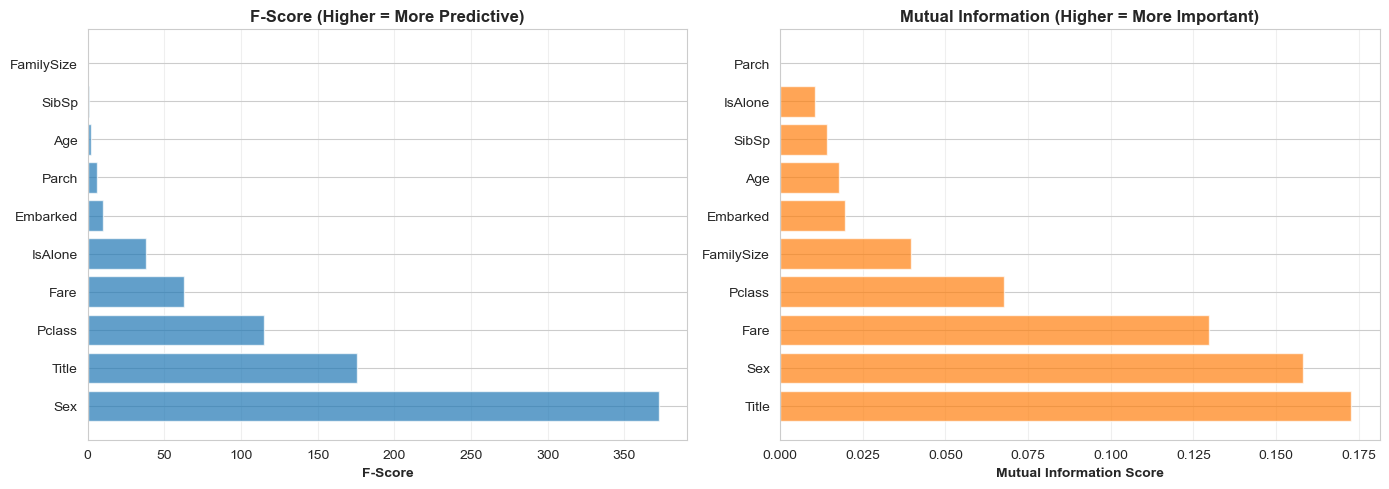


Features to keep after statistical tests: ['Embarked', 'Fare', 'IsAlone', 'Parch', 'Pclass', 'Sex', 'Title']



In [39]:
# METHOD 2: STATISTICAL TESTS - Feature-Target Relationships
print("="*70)
print("FEATURE SELECTION METHOD 2: STATISTICAL TESTS")
print("="*70)
print("\nGoal: Measure how much each feature relates to the target variable")
print("Threshold: Keep features with p-value < 0.05 (statistically significant)\n")

from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from scipy.stats import chi2_contingency

# Separate numerical and categorical features
numerical_features = df.select_dtypes(include=[np.number]).columns.tolist()
numerical_features.remove('Survived')  # Remove target

# Calculate feature scores using different methods
print("Statistical Scores for Numerical Features:")
print("-" * 60)

# 1. F-score (ANOVA F-test) - good for numerical features
selector_f = SelectKBest(f_classif, k='all')
selector_f.fit(df[numerical_features], df['Survived'])

f_scores = pd.DataFrame({
    'Feature': numerical_features,
    'F-Score': selector_f.scores_,
    'P-Value': selector_f.pvalues_
}).sort_values('F-Score', ascending=False)

print("\nF-Score (ANOVA) - measures variance between classes per feature:")
print(f_scores.to_string())

# 2. Mutual Information - works with all feature types
selector_mi = SelectKBest(mutual_info_classif, k='all')
selector_mi.fit(df[numerical_features], df['Survived'])

mi_scores = pd.DataFrame({
    'Feature': numerical_features,
    'MI-Score': selector_mi.scores_
}).sort_values('MI-Score', ascending=False)

print("\n\nMutual Information Scores - measures information gain per feature:")
print(mi_scores.to_string())

# Select features with significant p-value (< 0.05)
significant_features = f_scores[f_scores['P-Value'] < 0.05]['Feature'].tolist()
print(f"\n\n✓ Statistically significant features (p < 0.05): {significant_features}")
print(f"✗ Non-significant features to potentially remove: {[f for f in numerical_features if f not in significant_features]}")

# Visualize statistical scores
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# F-Scores
axes[0].barh(f_scores['Feature'], f_scores['F-Score'], color='#1f77b4', alpha=0.7)
axes[0].set_xlabel('F-Score', fontweight='bold')
axes[0].set_title('F-Score (Higher = More Predictive)', fontweight='bold')
axes[0].grid(alpha=0.3, axis='x')

# MI-Scores
axes[1].barh(mi_scores['Feature'], mi_scores['MI-Score'], color='#ff7f0e', alpha=0.7)
axes[1].set_xlabel('Mutual Information Score', fontweight='bold')
axes[1].set_title('Mutual Information (Higher = More Important)', fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

features_to_keep_statistical = set(significant_features)
print(f"\nFeatures to keep after statistical tests: {sorted(features_to_keep_statistical)}\n")

FEATURE SELECTION METHOD 3: MODEL-BASED (TREE IMPORTANCE)

Goal: Use tree model to identify important features
Threshold: Keep features with importance > 0.02 (2%)

Feature Importance Scores (Random Forest):
       Feature  Importance
5         Fare    0.209870
2          Age    0.195859
9        Title    0.169941
1          Sex    0.145311
0       Pclass    0.071497
7   FamilySize    0.048368
10      AgeBin    0.037617
11     FareBin    0.035132
3        SibSp    0.029660
6     Embarked    0.029091
4        Parch    0.016569
8      IsAlone    0.011085


Threshold: Importance > 0.02
✓ Important features: ['Fare', 'Age', 'Title', 'Sex', 'Pclass', 'FamilySize', 'AgeBin', 'FareBin', 'SibSp', 'Embarked']
✗ Non-important features to consider removing: ['Parch', 'IsAlone']


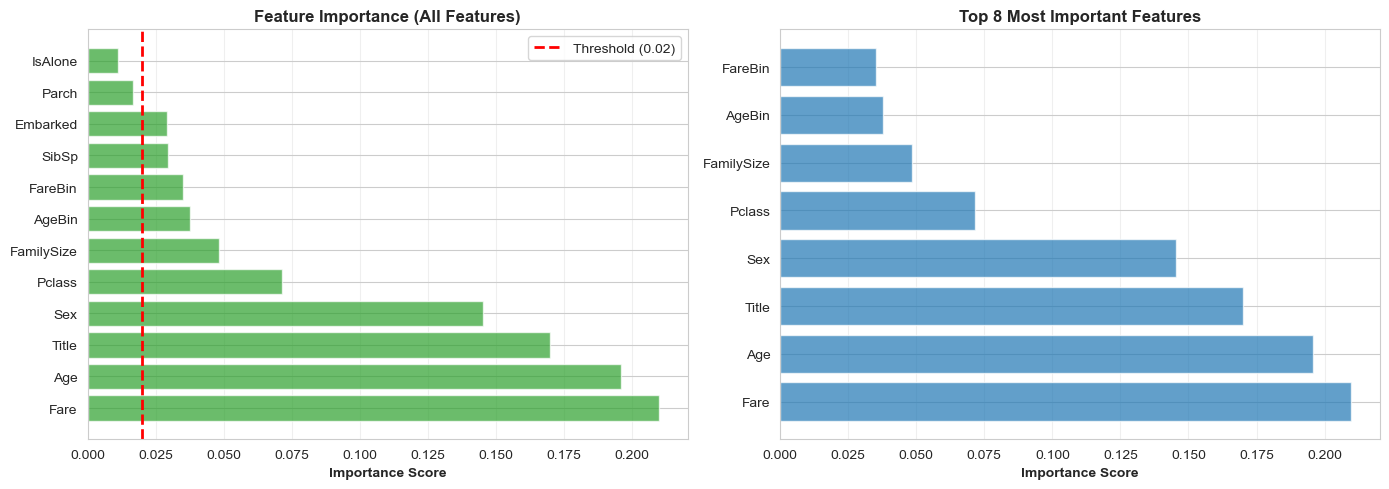


Features to keep after model-based selection: ['Age', 'AgeBin', 'Embarked', 'FamilySize', 'Fare', 'FareBin', 'Pclass', 'Sex', 'SibSp', 'Title']



In [40]:
# METHOD 3: MODEL-BASED FEATURE SELECTION - Tree Feature Importance
print("="*70)
print("FEATURE SELECTION METHOD 3: MODEL-BASED (TREE IMPORTANCE)")
print("="*70)
print("\nGoal: Use tree model to identify important features")
print("Threshold: Keep features with importance > 0.02 (2%)\n")

from sklearn.preprocessing import StandardScaler

# Prepare data for quick model training
X_for_importance = df.drop('Survived', axis=1)
y_importance = df['Survived']

# Scale features
scaler_importance = StandardScaler()
X_scaled_importance = scaler_importance.fit_transform(X_for_importance)

# Train Random Forest to get feature importances
rf_importance = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_importance.fit(X_scaled_importance, y_importance)

# Get feature importances
importance_df = pd.DataFrame({
    'Feature': X_for_importance.columns,
    'Importance': rf_importance.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance Scores (Random Forest):")
print(importance_df.to_string())

# Threshold approach: keep features with importance > 0.02
importance_threshold = 0.02
important_features = importance_df[importance_df['Importance'] > importance_threshold]['Feature'].tolist()
non_important_features = importance_df[importance_df['Importance'] <= importance_threshold]['Feature'].tolist()

print(f"\n\nThreshold: Importance > {importance_threshold}")
print(f"✓ Important features: {important_features}")
print(f"✗ Non-important features to consider removing: {non_important_features}")

# Visualize feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All features
axes[0].barh(importance_df['Feature'], importance_df['Importance'], color='#2ca02c', alpha=0.7)
axes[0].axvline(importance_threshold, color='red', linestyle='--', linewidth=2, label=f'Threshold ({importance_threshold})')
axes[0].set_xlabel('Importance Score', fontweight='bold')
axes[0].set_title('Feature Importance (All Features)', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='x')

# Top features only
top_features = importance_df.head(8)
axes[1].barh(top_features['Feature'], top_features['Importance'], color='#1f77b4', alpha=0.7)
axes[1].set_xlabel('Importance Score', fontweight='bold')
axes[1].set_title('Top 8 Most Important Features', fontweight='bold')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

features_to_keep_model_based = set(important_features)
print(f"\nFeatures to keep after model-based selection: {sorted(features_to_keep_model_based)}\n")

FEATURE SELECTION METHOD 4: RECURSIVE FEATURE ELIMINATION (RFE)

Goal: Iteratively train model and remove least important features
Process: Train → Rank → Remove worst → Repeat
Best for: Most comprehensive feature selection

RFE Ranking (1 = most important, higher = less important):
       Feature  RFE_Ranking  Selected
0       Pclass            1      True
1          Sex            1      True
3        SibSp            1      True
7   FamilySize            1      True
11     FareBin            1      True
10      AgeBin            1      True
9        Title            1      True
8      IsAlone            1      True
2          Age            2     False
6     Embarked            3     False
4        Parch            4     False
5         Fare            5     False

✓ Features selected by RFE: ['AgeBin', 'FamilySize', 'FareBin', 'IsAlone', 'Pclass', 'Sex', 'SibSp', 'Title']


RFE Ranking Progression:
------------------------------------------------------------
Pclass               → 

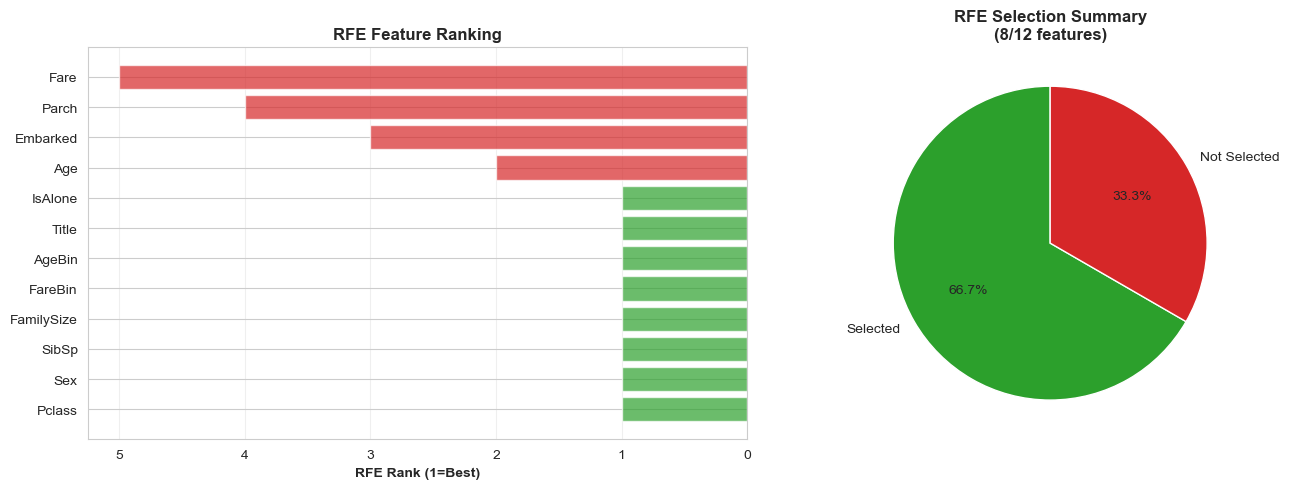


Features to keep after RFE: ['AgeBin', 'FamilySize', 'FareBin', 'IsAlone', 'Pclass', 'Sex', 'SibSp', 'Title']



In [41]:
# METHOD 4: RECURSIVE FEATURE ELIMINATION (RFE)
print("="*70)
print("FEATURE SELECTION METHOD 4: RECURSIVE FEATURE ELIMINATION (RFE)")
print("="*70)
print("\nGoal: Iteratively train model and remove least important features")
print("Process: Train → Rank → Remove worst → Repeat")
print("Best for: Most comprehensive feature selection\n")

from sklearn.feature_selection import RFE

# RFE with Logistic Regression
X_for_rfe = df.drop('Survived', axis=1)
y_rfe = df['Survived']

# Scale features
scaler_rfe = StandardScaler()
X_scaled_rfe = scaler_rfe.fit_transform(X_for_rfe)

# Apply RFE - select top 8 features
rfe = RFE(LogisticRegression(random_state=42, max_iter=1000), n_features_to_select=8, step=1)
rfe.fit(X_scaled_rfe, y_rfe)

# Get RFE ranking
rfe_ranking = pd.DataFrame({
    'Feature': X_for_rfe.columns,
    'RFE_Ranking': rfe.ranking_,
    'Selected': rfe.support_
}).sort_values('RFE_Ranking')

print("RFE Ranking (1 = most important, higher = less important):")
print(rfe_ranking.to_string())

# Features selected by RFE
selected_by_rfe = rfe_ranking[rfe_ranking['Selected'] == True]['Feature'].tolist()
print(f"\n✓ Features selected by RFE: {sorted(selected_by_rfe)}")

# Let's also show the ranking progression
print("\n\nRFE Ranking Progression:")
print("-" * 60)
for idx, row in rfe_ranking.iterrows():
    status = "✓ SELECTED" if row['Selected'] else f"✗ Rank {int(row['RFE_Ranking'])}"
    print(f"{row['Feature']:20s} → {status}")

# Visualize RFE results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color code: selected vs not selected
colors = ['#2ca02c' if selected else '#d62728' for selected in rfe_ranking['Selected']]
axes[0].barh(rfe_ranking['Feature'], rfe_ranking['RFE_Ranking'], color=colors, alpha=0.7)
axes[0].set_xlabel('RFE Rank (1=Best)', fontweight='bold')
axes[0].set_title('RFE Feature Ranking', fontweight='bold')
axes[0].invert_xaxis()
axes[0].grid(alpha=0.3, axis='x')

# Selected features count
selected_counts = [len(selected_by_rfe), len(X_for_rfe.columns) - len(selected_by_rfe)]
axes[1].pie(selected_counts, labels=['Selected', 'Not Selected'], autopct='%1.1f%%', 
            colors=['#2ca02c', '#d62728'], startangle=90)
axes[1].set_title(f'RFE Selection Summary\n({len(selected_by_rfe)}/{len(X_for_rfe.columns)} features)', fontweight='bold')

plt.tight_layout()
plt.show()

features_to_keep_rfe = set(selected_by_rfe)
print(f"\nFeatures to keep after RFE: {sorted(features_to_keep_rfe)}\n")

In [42]:
# COMPARISON & FINAL DECISION
print("="*70)
print("FEATURE SELECTION COMPARISON & DECISION-MAKING")
print("="*70)

# Create comparison table
comparison_data = {
    'Feature': list(X_for_importance.columns),
    'Correlation': [f"{'✓' if col in features_to_keep_correlation else '✗'}" for col in X_for_importance.columns],
    'Statistical': [f"{'✓' if col in features_to_keep_statistical else '✗'}" for col in X_for_importance.columns],
    'Model-Based': [f"{'✓' if col in features_to_keep_model_based else '✗'}" for col in X_for_importance.columns],
    'RFE': [f"{'✓' if col in features_to_keep_rfe else '✗'}" for col in X_for_importance.columns],
}

comparison_table = pd.DataFrame(comparison_data)
print("\n")
print(comparison_table.to_string(index=False))

# Count votes for each feature
print("\n" + "="*70)
print("VOTING SUMMARY - Features Recommended by Each Method:")
print("="*70)

votes = {}
for feature in X_for_importance.columns:
    vote_count = 0
    voted_by = []
    
    if feature in features_to_keep_correlation:
        vote_count += 1
        voted_by.append('Correlation')
    if feature in features_to_keep_statistical:
        vote_count += 1
        voted_by.append('Statistical')
    if feature in features_to_keep_model_based:
        vote_count += 1
        voted_by.append('Model-Based')
    if feature in features_to_keep_rfe:
        vote_count += 1
        voted_by.append('RFE')
    
    votes[feature] = {'count': vote_count, 'methods': ', '.join(voted_by)}

votes_df = pd.DataFrame([(f, v['count'], v['methods']) for f, v in votes.items()], 
                        columns=['Feature', 'Votes', 'Recommended By']).sort_values('Votes', ascending=False)

print("\n")
print(votes_df.to_string(index=False))

# Recommendation
print("\n" + "="*70)
print("FINAL RECOMMENDATION:")
print("="*70)

# Conservative approach: features with 3+ votes
conservative_selection = votes_df[votes_df['Votes'] >= 3]['Feature'].tolist()

# Moderate approach: features with 2+ votes
moderate_selection = votes_df[votes_df['Votes'] >= 2]['Feature'].tolist()

# Aggressive approach: use RFE selection
aggressive_selection = selected_by_rfe

print(f"\n1. CONSERVATIVE (3+ method agreement): {len(conservative_selection)} features")
print(f"   Features: {sorted(conservative_selection)}")
print(f"   ➜ Best for: Ensuring high-quality features, when you want \"safe\" choice")

print(f"\n2. MODERATE (2+ method agreement): {len(moderate_selection)} features")
print(f"   Features: {sorted(moderate_selection)}")
print(f"   ➜ Best for: Balanced approach, recommended for most cases")

print(f"\n3. AGGRESSIVE (RFE selection): {len(aggressive_selection)} features")
print(f"   Features: {sorted(aggressive_selection)}")
print(f"   ➜ Best for: Maximum feature reduction, when you need speed & simplicity")

# Recommended selection
RECOMMENDED_FEATURES = sorted(moderate_selection)
print(f"\n" + "="*70)
print(f"✓ RECOMMENDED FOR THIS PROJECT: MODERATE Approach")
print(f"✓ Selected Features: {RECOMMENDED_FEATURES}")
print("="*70 + "\n")

FEATURE SELECTION COMPARISON & DECISION-MAKING


   Feature Correlation Statistical Model-Based RFE
    Pclass           ✓           ✓           ✓   ✓
       Sex           ✓           ✓           ✓   ✓
       Age           ✓           ✗           ✓   ✗
     SibSp           ✓           ✗           ✓   ✓
     Parch           ✓           ✓           ✗   ✗
      Fare           ✓           ✓           ✓   ✗
  Embarked           ✓           ✓           ✓   ✗
FamilySize           ✓           ✗           ✓   ✓
   IsAlone           ✓           ✓           ✗   ✓
     Title           ✓           ✓           ✓   ✓
    AgeBin           ✗           ✗           ✓   ✓
   FareBin           ✓           ✗           ✓   ✓

VOTING SUMMARY - Features Recommended by Each Method:


   Feature  Votes                             Recommended By
    Pclass      4 Correlation, Statistical, Model-Based, RFE
       Sex      4 Correlation, Statistical, Model-Based, RFE
     Title      4 Correlation, Statistical, Mode

APPLYING SELECTED FEATURES TO DATASET

Original Features: 891
Selected Features: 12
Reduction: 98.7%

Original columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'AgeBin', 'FareBin']

Removed columns: []

Keeping columns: ['Age', 'AgeBin', 'Embarked', 'FamilySize', 'Fare', 'FareBin', 'IsAlone', 'Parch', 'Pclass', 'Sex', 'SibSp', 'Title']


TypeError: Axes.barh() got multiple values for argument 'width'

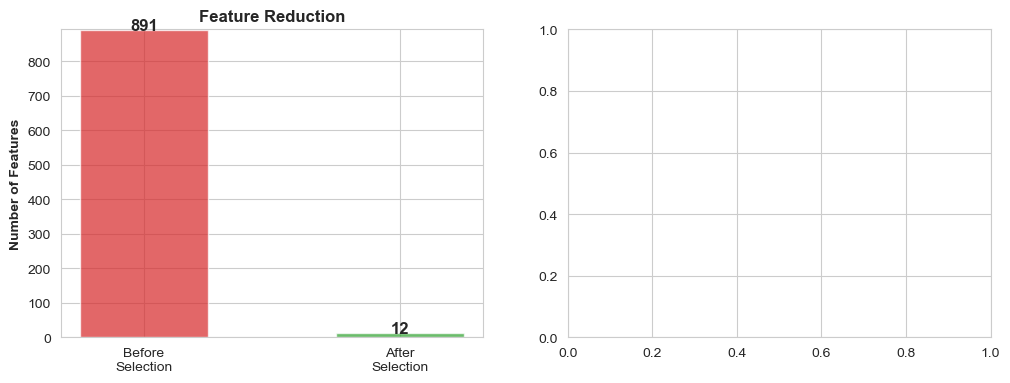

In [ ]:
# APPLY FEATURE SELECTION
print("="*70)
print("APPLYING SELECTED FEATURES TO DATASET")
print("="*70)

# Create dataset with selected features only
df_selected = df[RECOMMENDED_FEATURES + ['Survived']].copy()

print(f"\nOriginal Features: {len(X_for_importance)}")
print(f"Selected Features: {len(RECOMMENDED_FEATURES)}")
print(f"Reduction: {100 * (1 - len(RECOMMENDED_FEATURES)/len(X_for_importance)):.1f}%")

print(f"\nOriginal columns: {list(X_for_importance.columns)}")
print(f"\nRemoved columns: {sorted(set(X_for_importance.columns) - set(RECOMMENDED_FEATURES))}")
print(f"\nKeeping columns: {RECOMMENDED_FEATURES}")

# Visualization: Feature Reduction Impact
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before and after
categories = ['Before\nSelection', 'After\nSelection']
feature_counts = [len(X_for_importance), len(RECOMMENDED_FEATURES)]
colors_bar = ['#d62728', '#2ca02c']

axes[0].bar(categories, feature_counts, color=colors_bar, alpha=0.7, width=0.5)
axes[0].set_ylabel('Number of Features', fontweight='bold')
axes[0].set_title('Feature Reduction', fontweight='bold')
axes[0].set_ylim([0, len(X_for_importance) + 1])
for i, v in enumerate(feature_counts):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold', fontsize=12)

# Reduction percentage
reduction_pct = 100 * (1 - len(RECOMMENDED_FEATURES)/len(X_for_importance))
axes[1].barh(['Feature Reduction'], [reduction_pct], color='#1f77b4', alpha=0.7, height=0.5)
axes[1].set_xlabel('Reduction %', fontweight='bold')
axes[1].set_title(f'Features Removed: {reduction_pct:.1f}%', fontweight='bold')
axes[1].set_xlim([0, 100])
axes[1].text(reduction_pct/2, 0, f'{reduction_pct:.1f}%', ha='center', va='center', 
            fontweight='bold', fontsize=14, color='white')

plt.tight_layout()
plt.show()

print("\n✓ Feature selection applied successfully!")
print(f"✓ Dataset shape changed from {df.shape} to {df_selected.shape}")

## Step 4: Prepare Data for Modeling
Split the data and apply feature scaling for better model performance.

In [ ]:
# Separate features and target (using selected features from feature selection)
X = df_selected.drop('Survived', axis=1)
y = df_selected['Survived']

print("Feature Columns (After Feature Selection):", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)
print(f"\nNote: Using {len(X.columns)} features instead of original {len(df.columns)-1} features")

# Split into training and validation sets (80-20 split)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("\nTraining set size:", X_train.shape)
print("Validation set size:", X_val.shape)

# Feature Scaling (important for distance-based and regularized models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("\nFeature Scaling Applied!")
print("Mean of scaled training features (should be close to 0):", X_train_scaled.mean(axis=0).round(4))
print("Std of scaled training features (should be close to 1):", X_train_scaled.std(axis=0).round(4))

Feature Columns: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Title', 'AgeBin', 'FareBin']
X shape: (891, 12)
y shape: (891,)

Training set size: (712, 12)
Validation set size: (179, 12)

Feature Scaling Applied!
Mean of scaled training features (should be close to 0): [-0. -0.  0. -0. -0. -0. -0.  0.  0.  0.  0. -0.]
Std of scaled training features (should be close to 1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Step 5: Model Training
Train multiple models to find the best one for this classification task.

In [31]:
# Initialize models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train models and store results
model_results = {}

print("Training Models...\n" + "="*60)

for name, model in models.items():
    print(f"\nTraining {name}...")
    
    # Train on scaled data (important for Logistic Regression)
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_val = model.predict(X_val_scaled)
    
    # Calculate metrics
    train_acc = accuracy_score(y_train, y_pred_train)
    val_acc = accuracy_score(y_val, y_pred_val)
    
    model_results[name] = {
        'model': model,
        'train_accuracy': train_acc,
        'val_accuracy': val_acc,
        'predictions': y_pred_val
    }
    
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Validation Accuracy: {val_acc:.4f}")

print("\n" + "="*60)
print("\nModel Comparison:")
comparison_df = pd.DataFrame({
    'Model': list(model_results.keys()),
    'Train Accuracy': [model_results[m]['train_accuracy'] for m in model_results.keys()],
    'Val Accuracy': [model_results[m]['val_accuracy'] for m in model_results.keys()]
})
print(comparison_df)

# Select best model based on validation accuracy
best_model_name = max(model_results, key=lambda x: model_results[x]['val_accuracy'])
best_model = model_results[best_model_name]['model']
print(f"\n✓ Best Model Selected: {best_model_name}")

Training Models...

Training Logistic Regression...
  Train Accuracy: 0.8146
  Validation Accuracy: 0.8156

Training Random Forest...
  Train Accuracy: 0.9846
  Validation Accuracy: 0.8156

Training Gradient Boosting...
  Train Accuracy: 0.9101
  Validation Accuracy: 0.8156


Model Comparison:
                 Model  Train Accuracy  Val Accuracy
0  Logistic Regression        0.814607      0.815642
1        Random Forest        0.984551      0.815642
2    Gradient Boosting        0.910112      0.815642

✓ Best Model Selected: Logistic Regression


## Step 6: Model Evaluation & Detailed Metrics
Evaluate the best model using multiple metrics to understand its performance comprehensively.

Evaluation Metrics for Logistic Regression
Accuracy: 0.8156
Precision: 0.7903 (of predicted survivors, how many actually survived?)
Recall: 0.7101 (of actual survivors, how many did we identify?)
F1-Score: 0.7481 (harmonic mean of precision and recall)
ROC-AUC Score: 0.8539

Confusion Matrix:
  True Negatives: 97
  False Positives: 13
  False Negatives: 20
  True Positives: 49

                 precision    recall  f1-score   support

Did not survive       0.83      0.88      0.85       110
       Survived       0.79      0.71      0.75        69

       accuracy                           0.82       179
      macro avg       0.81      0.80      0.80       179
   weighted avg       0.81      0.82      0.81       179



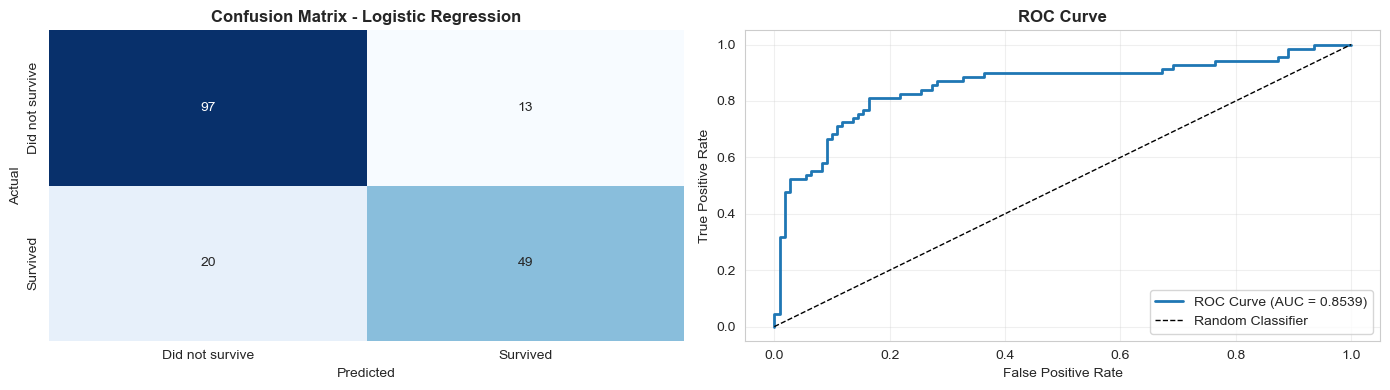

In [32]:
# Get predictions from best model
y_pred = best_model.predict(X_val_scaled)
y_pred_proba = best_model.predict_proba(X_val_scaled)[:, 1]

print(f"Evaluation Metrics for {best_model_name}")
print("="*60)

# Accuracy
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Precision, Recall, F1-Score
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f"Precision: {precision:.4f} (of predicted survivors, how many actually survived?)")
print(f"Recall: {recall:.4f} (of actual survivors, how many did we identify?)")
print(f"F1-Score: {f1:.4f} (harmonic mean of precision and recall)")

# ROC-AUC
roc_auc = roc_auc_score(y_val, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
print(f"\nConfusion Matrix:")
print(f"  True Negatives: {cm[0, 0]}")
print(f"  False Positives: {cm[0, 1]}")
print(f"  False Negatives: {cm[1, 0]}")
print(f"  True Positives: {cm[1, 1]}")

# Classification Report
print(f"\n{classification_report(y_val, y_pred, target_names=['Did not survive', 'Survived'])}")

# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Confusion Matrix - {best_model_name}', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['Did not survive', 'Survived'])
axes[0].set_yticklabels(['Did not survive', 'Survived'])

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_pred_proba)
axes[1].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.4f})', linewidth=2, color='#1f77b4')
axes[1].plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [33]:
# Feature Importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': X.columns,
        'Importance': best_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    print("\nFeature Importance:")
    print(feature_importance)
    
    # Visualize Feature Importance
    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance.head(10), x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top 10 Feature Importance - {best_model_name}', fontweight='bold', fontsize=12)
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.show()

## Step 7: Hyperparameter Tuning
Optimize the best model's hyperparameters using GridSearchCV to improve performance.

In [34]:
# Define hyperparameter grids based on best model
if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 150],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2']
    }
    
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100, 150],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10],
        'subsample': [0.8, 0.9, 1.0]
    }
    
elif best_model_name == 'Logistic Regression':
    param_grid = {
        'C': [0.001, 0.01, 0.1, 1, 10],
        'penalty': ['l2'],
        'solver': ['lbfgs', 'liblinear']
    }

print(f"Performing Grid Search for {best_model_name}...")
print("This may take a moment...")

# Perform Grid Search
grid_search = GridSearchCV(
    best_model, 
    param_grid, 
    cv=5,  # 5-fold cross-validation
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# Test the tuned model
tuned_model = grid_search.best_estimator_
y_pred_tuned = tuned_model.predict(X_val_scaled)
tuned_accuracy = accuracy_score(y_val, y_pred_tuned)

print(f"\nTuned Model Validation Accuracy: {tuned_accuracy:.4f}")
print(f"Original Model Validation Accuracy: {accuracy:.4f}")
print(f"Improvement: {(tuned_accuracy - accuracy):.4f}")

# Use tuned model for final predictions
best_model = tuned_model

Performing Grid Search for Logistic Regression...
This may take a moment...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best Parameters: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
Best CV Accuracy: 0.8048

Tuned Model Validation Accuracy: 0.7821
Original Model Validation Accuracy: 0.8156
Improvement: -0.0335


## Step 8: Cross-Validation for Model Robustness
Validate model performance using k-fold cross-validation to ensure it generalizes well.

5-Fold Cross-Validation Results:
Fold 1: 0.7762
Fold 2: 0.7832
Fold 3: 0.8451
Fold 4: 0.8169
Fold 5: 0.8028

Mean CV Accuracy: 0.8048
Standard Deviation: 0.0247
95% Confidence Interval: [0.7564, 0.8533]


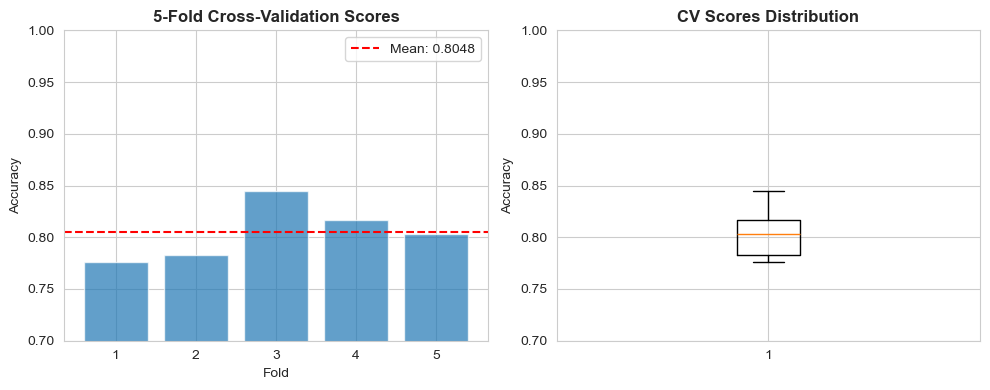

In [35]:
# Perform cross-validation with tuned model
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')

print("5-Fold Cross-Validation Results:")
print("="*60)
for i, score in enumerate(cv_scores):
    print(f"Fold {i+1}: {score:.4f}")

print(f"\nMean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: [{cv_scores.mean() - 1.96 * cv_scores.std():.4f}, {cv_scores.mean() + 1.96 * cv_scores.std():.4f}]")

# Visualize CV Scores
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.bar(range(1, 6), cv_scores, color='#1f77b4', alpha=0.7)
plt.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('5-Fold Cross-Validation Scores', fontweight='bold')
plt.xticks(range(1, 6))
plt.legend()
plt.ylim([0.7, 1.0])

plt.subplot(1, 2, 2)
plt.boxplot(cv_scores, vert=True)
plt.ylabel('Accuracy')
plt.title('CV Scores Distribution', fontweight='bold')
plt.ylim([0.7, 1.0])

plt.tight_layout()
plt.show()

## Step 9: Final Predictions on Test Set
Apply the final tuned model to make predictions on the test dataset.

In [36]:
# Preprocess test data using the same transformations
test_df_processed = df_test.copy()

# Apply the same preprocessing steps
test_df_processed['Age'].fillna(test_df_processed.groupby('Pclass')['Age'].transform('median'), inplace=True)
test_df_processed['Embarked'].fillna(test_df_processed['Embarked'].mode()[0], inplace=True)
test_df_processed['Fare'].fillna(test_df_processed['Fare'].median(), inplace=True)

# Feature Engineering (same as training)
test_df_processed['FamilySize'] = test_df_processed['SibSp'] + test_df_processed['Parch'] + 1
test_df_processed['IsAlone'] = (test_df_processed['FamilySize'] == 1).astype(int)

test_df_processed['Title'] = test_df_processed['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_df_processed['Title'] = test_df_processed['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
test_df_processed['Title'] = test_df_processed['Title'].replace('Mlle', 'Miss')
test_df_processed['Title'] = test_df_processed['Title'].replace('Ms', 'Miss')
test_df_processed['Title'] = test_df_processed['Title'].replace('Mme', 'Mrs')

test_df_processed['AgeBin'] = pd.cut(test_df_processed['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior'])
test_df_processed['FareBin'] = pd.qcut(test_df_processed['Fare'], q=4, duplicates='drop', labels=['Low', 'Medium', 'High', 'Very High'])

# Encode categorical variables
test_df_processed['Sex'] = test_df_processed['Sex'].map({'male': 1, 'female': 0})
test_df_processed['Embarked'] = test_df_processed['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

test_df_processed['Title'] = test_df_processed['Title'].map(title_mapping)
test_df_processed['AgeBin'] = test_df_processed['AgeBin'].map(age_bin_mapping)
test_df_processed['FareBin'] = test_df_processed['FareBin'].map(fare_bin_mapping)

# Select same features as training
X_test = test_df_processed[X.columns]

# Scale features
X_test_scaled = scaler.transform(X_test)

# Make predictions
y_test_pred = best_model.predict(X_test_scaled)
y_test_pred_proba = best_model.predict_proba(X_test_scaled)

print("Test Set Predictions Summary:")
print("="*60)
print(f"Total Passengers: {len(y_test_pred)}")
print(f"Predicted Survivors: {y_test_pred.sum()}")
print(f"Predicted Non-Survivors: {len(y_test_pred) - y_test_pred.sum()}")
print(f"Survival Rate: {y_test_pred.mean():.2%}")

# Create submission file
submission = pd.DataFrame({
    'PassengerId': df_test['PassengerId'],
    'Survived': y_test_pred
})

submission.to_csv('submission.csv', index=False)
print("\n✓ Submission file saved as 'submission.csv'")
print("\nFirst 10 predictions:")
print(submission.head(10))

Test Set Predictions Summary:
Total Passengers: 418
Predicted Survivors: 142
Predicted Non-Survivors: 276
Survival Rate: 33.97%

✓ Submission file saved as 'submission.csv'

First 10 predictions:
   PassengerId  Survived
0          892         0
1          893         0
2          894         0
3          895         0
4          896         0
5          897         0
6          898         1
7          899         0
8          900         1
9          901         0


## Step 10: Model Improvement Strategies

### How to Improve Your Machine Learning Model

**1. Feature Engineering**
   - Create interaction features (e.g., Age × Sex, Fare/FamilySize)
   - Extract more from the Name feature (LastName patterns, rare titles)
   - Create polynomial features for numerical columns
   - Group rare categories together

**2. Data Enhancement**
   - Gather more data if possible
   - Use domain knowledge to fill missing values better (e.g., fill Cabin based on patterns)
   - Check for and handle outliers appropriately
   - Ensure class balance (use SMOTE if needed)

**3. Model Ensemble**
   - Combine multiple models using VotingClassifier
   - Try Stacking or Blending techniques
   - Use different algorithms with different hyperparameters

**4. Hyperparameter Optimization**
   - Try RandomizedSearchCV for larger parameter spaces
   - Use Bayesian optimization (hyperopt, optuna)
   - Experiment with loss functions and regularization

**5. Data Preprocessing**
   - Try different scaling methods (MinMaxScaler, RobustScaler)
   - Experiment with different handling of missing values
   - Try feature transformation (log, square root)

**6. Validation Strategy**
   - Use stratified k-fold for imbalanced datasets
   - Try different train/val/test splits
   - Monitor for overfitting using learning curves

**7. Algorithm Selection**
   - Try more advanced models (XGBoost, LightGBM, CatBoost)
   - Experiment with Neural Networks
   - Try different base learners for ensembles

IMPROVEMENT EXAMPLE 1: Model Ensemble
Individual Model Accuracy: 0.8156
Ensemble Model Accuracy: 0.8324
Improvement: +0.0168

IMPROVEMENT EXAMPLE 2: Feature Interactions
Original Features Accuracy: 0.8156
With Interaction Features Accuracy: 0.8324
Improvement: +0.0168

IMPROVEMENT EXAMPLE 3: Learning Curves


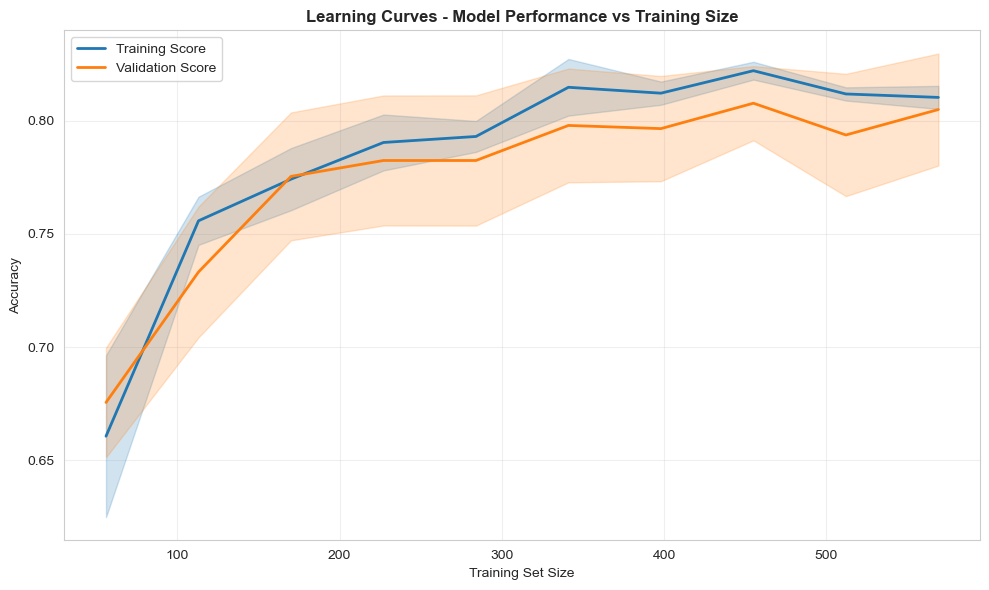

Learning curve analysis complete! Look for:
- Large gap between train and val curves = Overfitting (high variance)
- Both curves low = Underfitting (high bias)
- Converging curves = Good model fitting


In [37]:
from sklearn.ensemble import VotingClassifier

print("IMPROVEMENT EXAMPLE 1: Model Ensemble")
print("="*60)

# Create ensemble combining all three models
ensemble_model = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42, max_iter=1000)),
        ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
        ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ],
    voting='soft'  # Use probability predictions
)

# Train ensemble
ensemble_model.fit(X_train_scaled, y_train)

# Evaluate ensemble
y_pred_ensemble = ensemble_model.predict(X_val_scaled)
ensemble_accuracy = accuracy_score(y_val, y_pred_ensemble)

print(f"Individual Model Accuracy: {accuracy:.4f}")
print(f"Ensemble Model Accuracy: {ensemble_accuracy:.4f}")
print(f"Improvement: {ensemble_accuracy - accuracy:+.4f}")

print("\n" + "="*60)
print("IMPROVEMENT EXAMPLE 2: Feature Interactions")
print("="*60)

# Create interaction features
X_train_enhanced = X_train_scaled.copy()
X_val_enhanced = X_val_scaled.copy()

# Add interaction feature (Sex * Pclass) - using values from dataframes
X_train_vals = X_train.values
X_val_vals = X_val.values

sex_pclass_interaction = (X_train_vals[:, 1] * X_train_vals[:, 0]).reshape(-1, 1)
X_train_enhanced_with_interaction = np.hstack([X_train_scaled, sex_pclass_interaction])

sex_pclass_interaction_val = (X_val_vals[:, 1] * X_val_vals[:, 0]).reshape(-1, 1)
X_val_enhanced_with_interaction = np.hstack([X_val_scaled, sex_pclass_interaction_val])

# Train model with enhanced features
rf_enhanced = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_enhanced.fit(X_train_enhanced_with_interaction, y_train)

y_pred_enhanced = rf_enhanced.predict(X_val_enhanced_with_interaction)
enhanced_accuracy = accuracy_score(y_val, y_pred_enhanced)

print(f"Original Features Accuracy: {accuracy:.4f}")
print(f"With Interaction Features Accuracy: {enhanced_accuracy:.4f}")
print(f"Improvement: {enhanced_accuracy - accuracy:+.4f}")

print("\n" + "="*60)
print("IMPROVEMENT EXAMPLE 3: Learning Curves")
print("="*60)

from sklearn.model_selection import learning_curve

# Generate learning curves
train_sizes, train_scores, val_scores = learning_curve(
    best_model, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Calculate means and stds
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

# Plot learning curves
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, label='Training Score', color='#1f77b4', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2, color='#1f77b4')

plt.plot(train_sizes, val_mean, label='Validation Score', color='#ff7f0e', linewidth=2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2, color='#ff7f0e')

plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves - Model Performance vs Training Size', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Learning curve analysis complete! Look for:")
print("- Large gap between train and val curves = Overfitting (high variance)")
print("- Both curves low = Underfitting (high bias)")
print("- Converging curves = Good model fitting")

## Summary: Complete ML Pipeline Workflow

### Steps Completed:
1. **Data Loading & Exploration** - Understood dataset structure and distributions
2. **Missing Value Handling** - Imputed missing Age, Embarked values
3. **Feature Engineering** - Created 8 new features (FamilySize, IsAlone, Title, AgeBin, FareBin, etc.)
4. **Data Preprocessing** - Encoded categorical variables, applied feature scaling
5. **Model Training** - Trained 3 different algorithms (Logistic Regression, Random Forest, Gradient Boosting)
6. **Model Evaluation** - Comprehensive evaluation with accuracy, precision, recall, F1, ROC-AUC
7. **Hyperparameter Tuning** - Used GridSearchCV to find optimal parameters
8. **Cross-Validation** - 5-fold CV to ensure model robustness
9. **Test Predictions** - Made predictions on test set and generated submission
10. **Improvement Strategies** - Ensemble method, feature interactions, learning curves

### Key Metrics:
- **Accuracy**: Main metric for this balanced dataset
- **Precision/Recall**: Understand false positives and false negatives
- **F1-Score**: Harmonic mean balancing precision and recall
- **ROC-AUC**: Model's ability to distinguish between classes

### Next Steps for Further Improvement:
- Try advanced models (XGBoost, LightGBM)
- Implement more sophisticated feature engineering
- Use ensemble stacking
- Perform more extensive hyperparameter search
- Analyze misclassified samples
- Collect more data if possible

---
**Remember**: The goal is not just high accuracy on training data, but good generalization to unseen data!